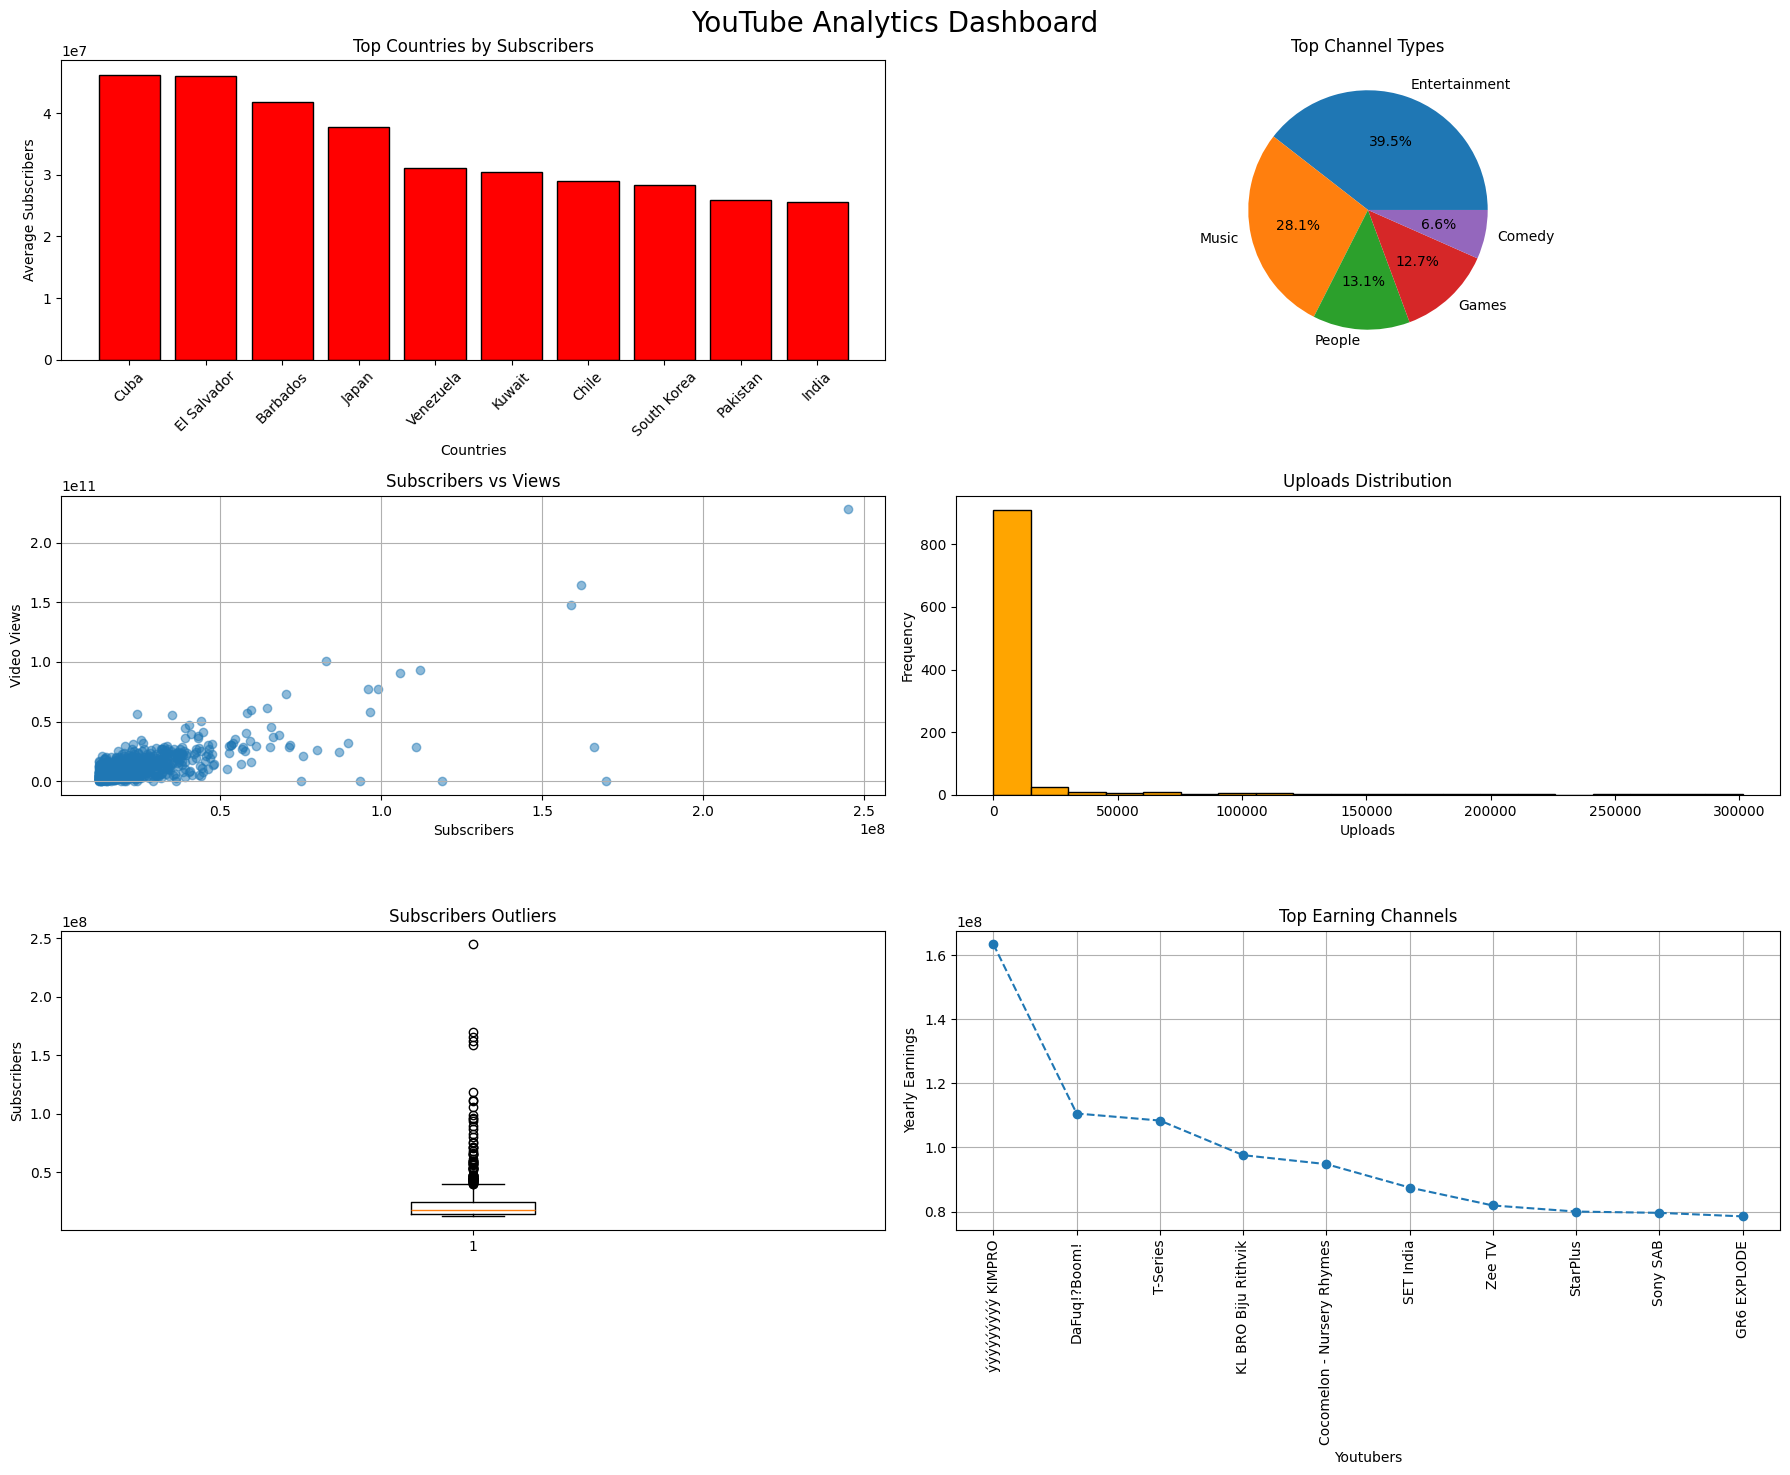

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df= pd.read_csv("Global YouTube Statistics.csv",encoding="latin1")
print(df.head())

print(df.shape)
print(df.info())
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())
print(df.drop_duplicates())
print(df.duplicated().sum())

df['Country']=df["Country"].fillna('Unknown')
df['channel_type']=df['channel_type'].fillna('Unknown')

numerical_columns= [
 'subscribers', 'video views', 'uploads' , 'highest_yearly_earnings','lowest_yearly_earnings','subscribers_for_last_30_days','Gross tertiary education enrollment (%)','Population','Unemployment rate','Urban_population'
    
]

for col in numerical_columns:
    df[col]=df[col].astype(str).str.replace(',','')
    df[col]=pd.to_numeric(df[col],errors="coerce")

for col in numerical_columns:
    df[col]=df[col].fillna(df[col].median())

print(df.isnull().sum())


top_ten= df[['Youtuber','subscribers']].sort_values(by="subscribers",ascending=False).head(10)
print(top_ten)
plt.bar(top_ten['Youtuber'],top_ten['subscribers'],color="red",edgecolor="red",label="top subscribers")
plt.title("top 10 subscribers")
plt.xlabel("youtube channel")
plt.ylabel("subscribers")
plt.legend()
plt.grid(True)
plt.xticks(rotation=90)
# df.figure(figsize=(20,15))
plt.savefig("top_10_subs.png")
plt.show()



# 2. Top 10 Channels by Video Views

top_tens= df[['Youtuber','video views']].sort_values(by="video views",ascending=False).head(10)
print(top_tens)

plt.barh(top_tens['Youtuber'], top_tens['video views'],color="blue")
plt.title("top 10 by views ")
plt.xlabel("video views")
plt.ylabel("Youtuber")
plt.xticks(rotation=90)
plt.savefig("top_10_views.png")
plt.show()


#histogram 
subs= df['subscribers']
plt.figure(figsize=(8,5))
plt.hist(subs,bins=4,edgecolor="black",color="red")
plt.title("range o subscriber channels ")
plt.xlabel("subscrivbers range")
plt.ylabel("Youtube channel")
plt.savefig("hilsto.png")
plt.grid(True)
plt.show()



ch_count= df['category'].value_counts().head(5)
print(ch_count)

plt.pie( ch_count.values,labels=ch_count.index, autopct="%1.1f%%",shadow=True)
plt.title("catogory distribution data")
plt.savefig("cat_dist.png")
plt.show()


cont_count= df['Country'].value_counts().head(10)
print(cont_count)

plt.barh(cont_count.index , cont_count.values,color="red")
plt.title("top country on youtube")
plt.xlabel("number of youtubers")
plt.ylabel("Countary names")
plt.savefig("top_cont.png")
plt.show()

plt.figure(figsize= (10,6))
plt.scatter(df['subscribers'], df['video views'],marker="o",color="black")
plt.xlabel("subscribers")
plt.ylabel("video views")
plt.grid(True)
plt.title("subscriber vs video views")
plt.savefig("subs_vs_views.png")
plt.show()

earning = df[['Youtuber','highest_monthly_earnings']].sort_values(by="highest_monthly_earnings" ,ascending=False).head(10)
plt.plot(earning['Youtuber'],earning['highest_monthly_earnings'],color="blue",linestyle="--",linewidth=3,marker="s",label="highest earning",markerfacecolor="red")
plt.xlabel("Youtuber")
plt.ylabel("highest_monthly_earnings")
plt.grid(True)
plt.title("monthly  earning of top youtubers")
plt.savefig("subs_vs_views.png")
plt.legend()
plt.xticks(rotation=90)
plt.show()


#scatter subplots of mutiple analysis of data 

fig,ax= plt.subplots(2,2,figsize=(12,8))

ax[0,0].scatter(df['subscribers'],df['video views'],marker="o",color="red")
ax[0,0].set_title("subscribbers vs video views")
ax[0,0].set_xlabel("subscribers")
ax[0,0].set_ylabel("video views")

ax[0,1].scatter(df['subscribers'],df['uploads'],marker="s",color="blue")
ax[0,1].set_title("subscribbers vs uploads")
ax[0,1].set_xlabel("subscribers")
ax[0,1].set_ylabel("uploads")

ax[1,0].scatter(df['video views'],df['highest_monthly_earnings'],marker="d",color="green",alpha=0.6,s=50)
ax[1,0].set_title("video views vs highest_monthly_earnings")
ax[1,0].set_xlabel("video_views")
ax[1,0].set_ylabel("highest_monthly_earnings")

ax[1,1].scatter(df['uploads'],df['highest_monthly_earnings'],marker="D",color="grey",alpha=0.8,s=50)
ax[1,1].set_title("uploads vs highest_monthly_earnings")
ax[1,1].set_xlabel("uploads")
ax[1,1].set_ylabel("highest_monthly_earnings")


fig.suptitle("analysis between veiws ,subs, ear etc")
plt.tight_layout()
plt.show()



i want to draw multiple bars on avg subscriber for all type , views for all type graph 

group_data= (df.groupby('Youtuber')[['subscribers','video views']].mean().sort_values(by="subscribers",ascending=False).head(10))
x=np.arange(len(group_data.index))
width=0.4

plt.bar(x,group_data['subscribers'],width=width,edgecolor="black",color="red",label="subscribers chart")
plt.bar(x+width,group_data['video views'] / 1000,width=width,edgecolor="black",color="blue",label="views chart")

plt.xticks(x+width/2,group_data.index,rotation=90)

plt.xlabel("youtube channel")
plt.ylabel("values")
plt.title("subs and views graph")
plt.legend()
plt.savefig("subs_views_bar.png")
plt.show()


plt.figure(figsize=(8,6))

plt.boxplot(df["subscribers"])
plt.ylabel("subscribers")
plt.title("Subscribers Box Plot")
plt.show()


plt.boxplot(df["video views"])
plt.show()


plt.figure(figsize=(10,6))
plt.boxplot([df['subscribers'],df['video views'],df['uploads']])
plt.xticks([1,2,3], ['subscribers','video views','uploads'])

plt.ylabel("valiues")
plt.grid(True)
plt.show()



top_channels= (df.sort_values(by="subscribers", ascending=False).head(10))

plt.figure(figsize=(12,6))
plt.fill_between(top_channels['Youtuber'], top_channels['subscribers'])
plt.xlabel("Youtuber")
plt.ylabel('subscribers')
plt.title("are ploting of you and sub")
plt.savefig("you_sub_area.png")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


#stack plots 

top_chan=(df.sort_values(by="subscribers",ascending=False).head(10))

plt.figure(figsize=(12,6))
x=np.arange(len(top_chan))
plt.stackplot(x, top_chan['subscribers'], top_chan['video views']/1000, labels= ["subscribers", "video views"])
plt.xticks(x, top_chan["Youtuber"],rotation=90)
plt.legend()
plt.grid()
plt.show()


#15 heatmap corelation of every column with every other column
numerical_data= df[['subscribers','video views','uploads','highest_monthly_earnings']]
corr_matrix= numerical_data.corr()  #finds the related columns in the range of -1 to 1.
print(corr_matrix)


# #16. Country-wise Earnings Analysis
# Create
# stacked bar chart
# Insights
# Which countries generate highest creator economy?


earning= (df.groupby('Country')[['highest_yearly_earnings', 'lowest_yearly_earnings']].mean().sort_values(by='highest_yearly_earnings', ascending=False).head(20))
x=np.arange(len(earning))

plt.stackplot(x, earning['highest_yearly_earnings'], earning['lowest_yearly_earnings'], labels=['highest_yearly_earnings','lowest_yearly_earnings'])
plt.legend()
plt.grid()
plt.title("highest vs lowest earning")
plt.savefig("high_vs_low.png")
plt.xticks(x, earning.index,rotation=45)
plt.show()



#Final assignments 
import matplotlib.pyplot as plt
import numpy as np

# create dashboard
fig, ax = plt.subplots(3, 2, figsize=(18,15))



top_countries = (
    df.groupby('Country')['subscribers']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

ax[0,0].bar(
    top_countries.index,
    top_countries.values,
    color='red',
    edgecolor='black'
)

ax[0,0].set_title("Top Countries by Subscribers")

ax[0,0].set_xlabel("Countries")

ax[0,0].set_ylabel("Average Subscribers")

ax[0,0].tick_params(axis='x', rotation=45)



channel_types = (
    df['channel_type']
    .value_counts()
    .head(5)
)

ax[0,1].pie(
    channel_types,
    labels=channel_types.index,
    autopct='%1.1f%%'
)

ax[0,1].set_title("Top Channel Types")



ax[1,0].scatter(
    df['subscribers'],
    df['video views'],
    alpha=0.5
)

ax[1,0].set_title("Subscribers vs Views")

ax[1,0].set_xlabel("Subscribers")

ax[1,0].set_ylabel("Video Views")

ax[1,0].grid()



ax[1,1].hist(
    df['uploads'],
    bins=20,
    color='orange',
    edgecolor='black'
)

ax[1,1].set_title("Uploads Distribution")

ax[1,1].set_xlabel("Uploads")

ax[1,1].set_ylabel("Frequency")



ax[2,0].boxplot(df['subscribers'])

ax[2,0].set_title("Subscribers Outliers")

ax[2,0].set_ylabel("Subscribers")



top_earnings = (
    df.sort_values(
        by='highest_yearly_earnings',
        ascending=False
    )
    .head(10)
)

ax[2,1].plot(
    top_earnings['Youtuber'],
    top_earnings['highest_yearly_earnings'],
    
    marker='o',
    linestyle='--'
)

ax[2,1].set_title("Top Earning Channels")

ax[2,1].set_xlabel("Youtubers")

ax[2,1].set_ylabel("Yearly Earnings")

ax[2,1].tick_params(axis='x', rotation=90)

ax[2,1].grid()

# ==================================================
# MAIN TITLE
# ==================================================

fig.suptitle(
    "YouTube Analytics Dashboard",
    fontsize=20
)

# spacing
plt.tight_layout()

# save dashboard
plt.savefig("youtube_dashboard.png")

# show dashboard
plt.show()






